In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

engine = create_engine(
    "mysql+pymysql://root:@localhost:3309/ecommerce_analytics1"
)

print("Database Connected Successfully!")

# Total Sellers KPI
query = """
SELECT COUNT(*) AS total_sellers
FROM sellers;
"""

total_sellers = pd.read_sql(query, engine)

total_sellers

# Sellers by State
query = """
SELECT
    seller_state,
    COUNT(*) AS total_sellers
FROM sellers
GROUP BY seller_state
ORDER BY total_sellers DESC;
"""

seller_states = pd.read_sql(query, engine)

seller_states.head()

Database Connected Successfully!


,seller_state,total_sellers
0,SP,1849
1,PR,349
2,MG,244
3,SC,190
4,RJ,171


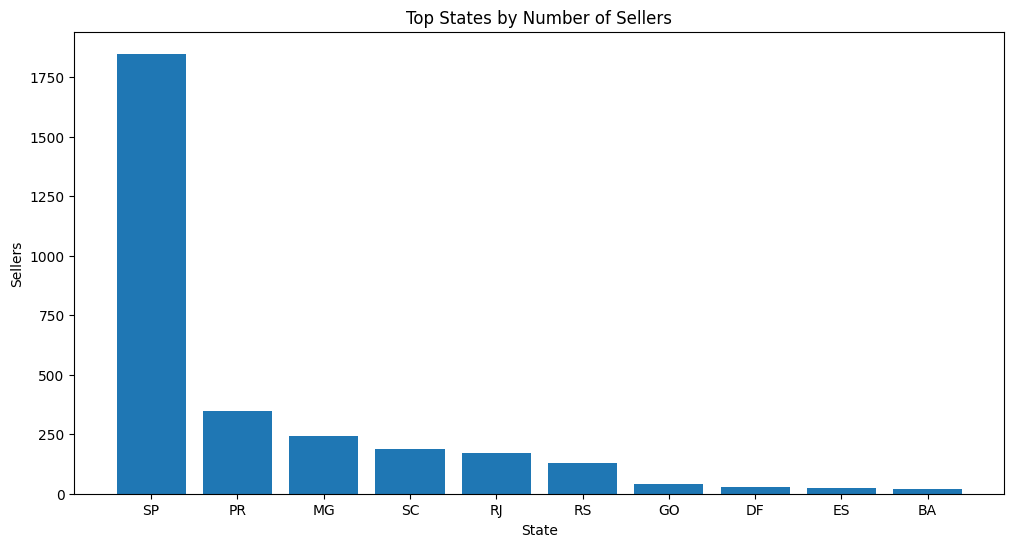

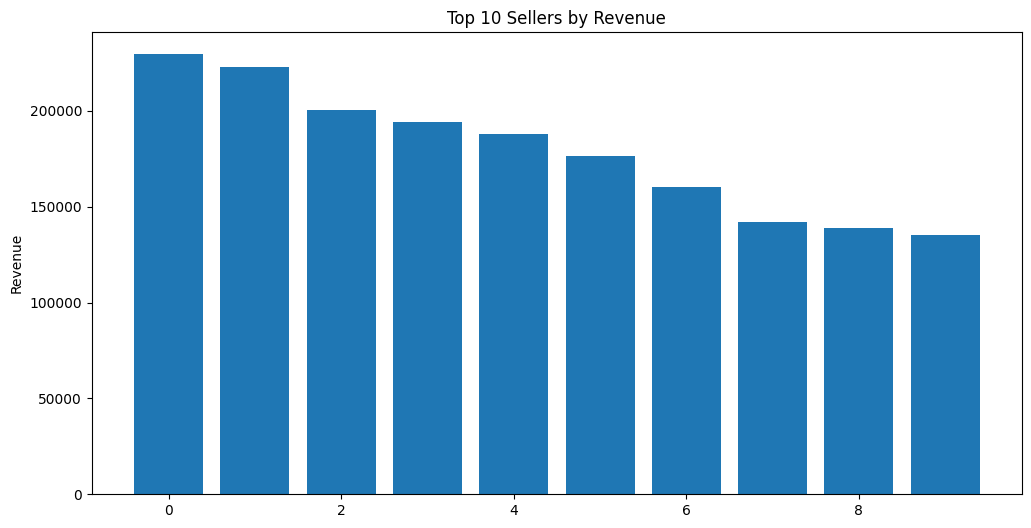

In [3]:
 # State-wise Seller Chart
plt.figure(figsize=(12,6))

plt.bar(
    seller_states.head(10)['seller_state'],
    seller_states.head(10)['total_sellers']
)

plt.title("Top States by Number of Sellers")
plt.xlabel("State")
plt.ylabel("Sellers")

plt.show()

# Top Sellers by Revenue
query = """
SELECT
    seller_id,
    ROUND(SUM(price),2) AS revenue
FROM order_items
GROUP BY seller_id
ORDER BY revenue DESC
LIMIT 10;
"""

top_sellers = pd.read_sql(query, engine)

top_sellers

# Revenue Chart
plt.figure(figsize=(12,6))

plt.bar(
    range(len(top_sellers)),
    top_sellers['revenue']
)

plt.title("Top 10 Sellers by Revenue")
plt.ylabel("Revenue")

plt.show()

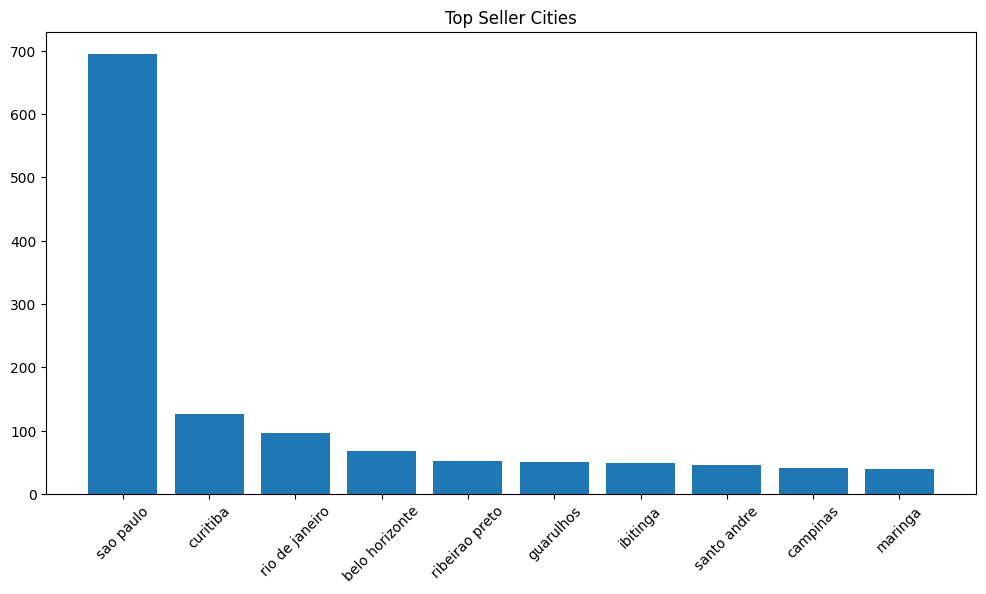

In [4]:
# Sellers with Most Orders
query = """
SELECT
    seller_id,
    COUNT(DISTINCT order_id) AS total_orders
FROM order_items
GROUP BY seller_id
ORDER BY total_orders DESC
LIMIT 10;
"""

seller_orders = pd.read_sql(query, engine)

seller_orders

# Seller Cities
query = """
SELECT
    seller_city,
    COUNT(*) AS total_sellers
FROM sellers
GROUP BY seller_city
ORDER BY total_sellers DESC
LIMIT 10;
"""

seller_cities = pd.read_sql(query, engine)

seller_cities

# Seller Cities Chart
plt.figure(figsize=(12,6))

plt.bar(
    seller_cities['seller_city'],
    seller_cities['total_sellers']
)

plt.xticks(rotation=45)

plt.title("Top Seller Cities")

plt.show()

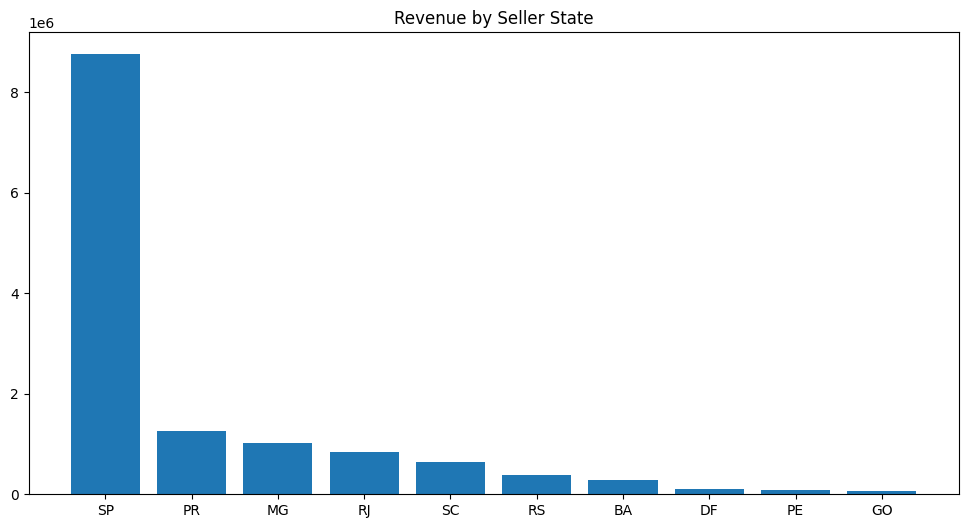

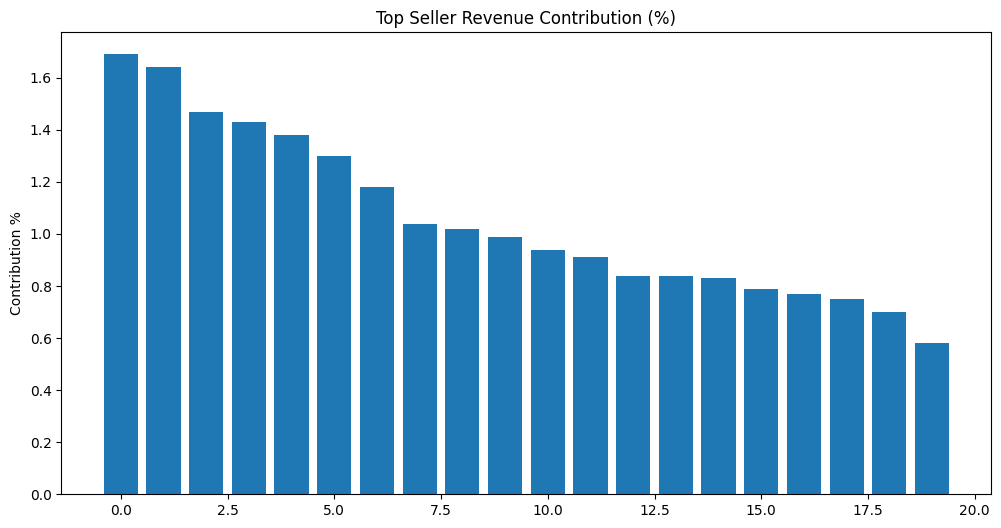

Seller Analysis Insights
------------------------
Total Sellers: 3095
Top Revenue Seller: 4869f7a5dfa277a7dca6462dcf3b52b2
Highest Seller State: SP
Top Seller City: sao paulo


In [5]:
# Revenue by Seller State
query = """
SELECT
    s.seller_state,
    ROUND(SUM(oi.price),2) AS revenue
FROM sellers s
JOIN order_items oi
ON s.seller_id = oi.seller_id
GROUP BY s.seller_state
ORDER BY revenue DESC;
"""

state_revenue = pd.read_sql(query, engine)

state_revenue.head()

# Revenue by State Chart
plt.figure(figsize=(12,6))

plt.bar(
    state_revenue.head(10)['seller_state'],
    state_revenue.head(10)['revenue']
)

plt.title("Revenue by Seller State")

plt.show()

# Average Order Value per Seller
query = """
SELECT
    seller_id,
    ROUND(AVG(price),2) AS avg_order_value
FROM order_items
GROUP BY seller_id
ORDER BY avg_order_value DESC
LIMIT 20;
"""

seller_aov = pd.read_sql(query, engine)

seller_aov.head()

# Seller Contribution %
query = """
SELECT
    seller_id,
    ROUND(
        SUM(price) * 100 /
        (SELECT SUM(price) FROM order_items),
        2
    ) AS contribution_pct
FROM order_items
GROUP BY seller_id
ORDER BY contribution_pct DESC
LIMIT 20;
"""

seller_contribution = pd.read_sql(query, engine)

seller_contribution.head()

# Top Seller Contribution Chart
plt.figure(figsize=(12,6))

plt.bar(
    range(len(seller_contribution)),
    seller_contribution['contribution_pct']
)

plt.title("Top Seller Revenue Contribution (%)")
plt.ylabel("Contribution %")

plt.show()

# Bottom Sellers by Revenue
query = """
SELECT
    seller_id,
    ROUND(SUM(price),2) AS revenue
FROM order_items
GROUP BY seller_id
ORDER BY revenue ASC
LIMIT 10;
"""

bottom_sellers = pd.read_sql(query, engine)

bottom_sellers

# Insights
print("Seller Analysis Insights")
print("------------------------")

print("Total Sellers:",
      total_sellers.iloc[0,0])

print("Top Revenue Seller:",
      top_sellers.iloc[0]['seller_id'])

print("Highest Seller State:",
      seller_states.iloc[0]['seller_state'])

print("Top Seller City:",
      seller_cities.iloc[0]['seller_city'])